# Model V2: Multi-Task Ordinal Classifier

**Improvements over V1:**
1. **Ordinal soft-label loss** for condition (Gaussian-smoothed targets + KL divergence)
2. **Multi-task heads** for stains, holes, and pilling (weighted CE)
3. **Class-weighted losses** for imbalanced auxiliary tasks

Architecture: Dual-stream EfficientNet-B2 (shared backbone) → concatenated 2816-d features → 4 task heads

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {DEVICE}")

CSV_PATH = Path("../data/cleaned_metadata_v2.csv")
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows  |  train={len(df[df.split=='train']):,}  test={len(df[df.split=='test']):,}")
print(f"Columns: {list(df.columns)}")

Using device: mps
Loaded 31,936 rows  |  train=25,548  test=6,388
Columns: ['timestamp', 'station', 'front_path', 'back_path', 'condition', 'pilling', 'stains', 'holes', 'smell', 'usage', 'material', 'category', 'clothing_type', 'is_fraud_candidate', 'split']


### Class Distribution & Weights

Compute inverse-frequency weights for the imbalanced auxiliary tasks (stains, holes).

In [3]:
train_df = df[df["split"] == "train"]
test_df  = df[df["split"] == "test"]

def inverse_freq_weights(series, num_classes, max_weight=10.0):
    """Compute inverse-frequency class weights, capped at max_weight."""
    counts = series.value_counts().sort_index()
    total = len(series)
    weights = []
    for c in range(num_classes):
        n = counts.get(c, 1)
        w = min(total / (num_classes * n), max_weight)
        weights.append(w)
    return torch.tensor(weights, dtype=torch.float32)

stains_weights = inverse_freq_weights(train_df["stains"], 3)
holes_weights  = inverse_freq_weights(train_df["holes"], 3)

print("Stains distribution (train):")
print(train_df["stains"].value_counts().sort_index())
print(f"Weights: {stains_weights}")
print()
print("Holes distribution (train):")
print(train_df["holes"].value_counts().sort_index())
print(f"Weights: {holes_weights}")
print()
print("Condition distribution (train):")
print((train_df["condition"] - 1).value_counts().sort_index())
print()
print("Pilling distribution (train):")
print((train_df["pilling"] - 1).value_counts().sort_index())

Stains distribution (train):
stains
0    19278
1     4191
2     2079
Name: count, dtype: int64
Weights: tensor([0.4417, 2.0320, 4.0962])

Holes distribution (train):
holes
0    24254
1      768
2      526
Name: count, dtype: int64
Weights: tensor([ 0.3511, 10.0000, 10.0000])

Condition distribution (train):
condition
0     874
1    4051
2    7821
3    6212
4    6590
Name: count, dtype: int64

Pilling distribution (train):
pilling
0      545
1     1818
2     3993
3     6059
4    13133
Name: count, dtype: int64


### Dataset and DataLoader

In [4]:
IMG_SIZE = 260

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=20, scale=(0.85, 1.15), shear=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


class ClothingDataset(Dataset):
    """Returns front/back images + multi-task labels."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        front = Image.open(row["front_path"]).convert("RGB")
        back  = Image.open(row["back_path"]).convert("RGB")

        if self.transform:
            front = self.transform(front)
            back  = self.transform(back)

        labels = {
            "condition": torch.tensor(row["condition"] - 1, dtype=torch.long),  # 0-4
            "stains":    torch.tensor(row["stains"],        dtype=torch.long),  # 0-2
            "holes":     torch.tensor(row["holes"],         dtype=torch.long),  # 0-2
            "pilling":   torch.tensor(row["pilling"] - 1,   dtype=torch.long),  # 0-4
            "fraud":     torch.tensor(float(row["is_fraud_candidate"]), dtype=torch.float),
        }
        return front, back, labels

In [5]:
BATCH_SIZE = 32

train_dataset = ClothingDataset(train_df, transform=train_transforms)
test_dataset  = ClothingDataset(test_df,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset):,} items → {len(train_loader):,} batches")
print(f"Test:  {len(test_dataset):,} items → {len(test_loader):,} batches")

# Sanity check
fronts, backs, labels = next(iter(train_loader))
print(f"\nFront: {fronts.shape}  Back: {backs.shape}")
for k, v in labels.items():
    print(f"  {k}: {v.shape}  range [{v.min().item()}, {v.max().item()}]")

Train: 25,548 items → 799 batches
Test:  6,388 items → 200 batches

Front: torch.Size([32, 3, 260, 260])  Back: torch.Size([32, 3, 260, 260])
  condition: torch.Size([32])  range [0, 4]
  stains: torch.Size([32])  range [0, 2]
  holes: torch.Size([32])  range [0, 2]
  pilling: torch.Size([32])  range [0, 4]
  fraud: torch.Size([32])  range [0.0, 0.0]


### Ordinal Soft-Label Loss

Instead of treating condition 1-5 as independent categories, we create Gaussian-smoothed target distributions. Predicting condition 1 when true is 5 gets penalized much more than predicting 4.

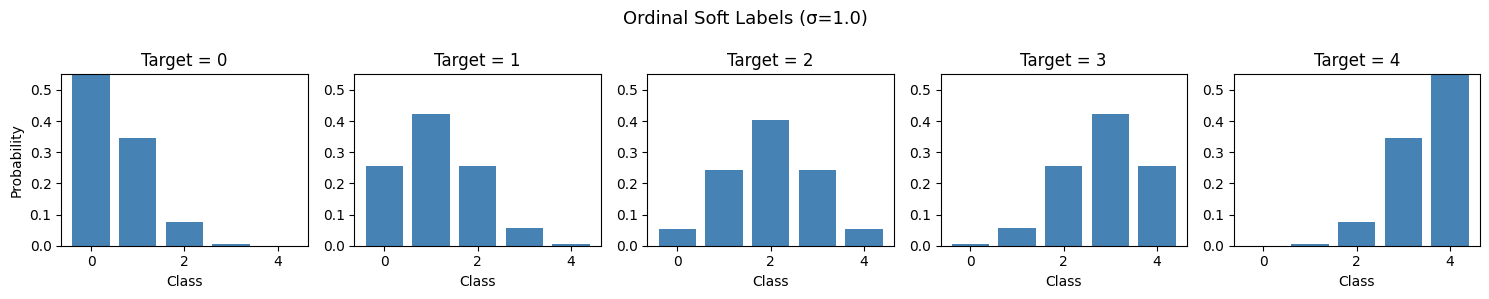

In [6]:
def ordinal_soft_labels(targets, num_classes=5, sigma=1.0):
    """
    Convert hard integer targets to Gaussian-smoothed probability distributions.
    
    Example with sigma=1.0, target=2:
        class 0: exp(-2.0) = 0.135  (2 away → low)
        class 1: exp(-0.5) = 0.607  (1 away → medium)
        class 2: exp( 0.0) = 1.000  (exact  → high)
        class 3: exp(-0.5) = 0.607  (1 away → medium)
        class 4: exp(-2.0) = 0.135  (2 away → low)
    → normalized to sum to 1.
    """
    classes = torch.arange(num_classes, device=targets.device).float()
    targets_f = targets.float().unsqueeze(1)  # (B, 1)
    soft = torch.exp(-0.5 * ((classes - targets_f) / sigma) ** 2)
    soft = soft / soft.sum(dim=1, keepdim=True)
    return soft


def ordinal_kl_loss(logits, targets, num_classes=5, sigma=1.0):
    """KL divergence between predicted log-probs and ordinal soft targets."""
    soft_targets = ordinal_soft_labels(targets, num_classes, sigma)
    log_probs = F.log_softmax(logits, dim=1)
    return F.kl_div(log_probs, soft_targets, reduction='batchmean')


# Visualize what the soft labels look like
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for target in range(5):
    t = torch.tensor([target])
    soft = ordinal_soft_labels(t, num_classes=5, sigma=1.0).squeeze()
    axes[target].bar(range(5), soft.numpy(), color='steelblue')
    axes[target].set_title(f'Target = {target}')
    axes[target].set_ylim(0, 0.55)
    axes[target].set_xlabel('Class')
    if target == 0:
        axes[target].set_ylabel('Probability')
fig.suptitle('Ordinal Soft Labels (σ=1.0)', fontsize=13)
plt.tight_layout()
plt.show()

### Multi-Task Model Architecture

Same dual-stream EfficientNet-B2 backbone, but now with 4 output heads:
- **Condition** (primary): 5-class ordinal regression
- **Stains**: 3-class classification (none/minor/major)
- **Holes**: 3-class classification (none/minor/major)
- **Pilling**: 5-class classification (1-5 scale)

In [7]:
import timm

class ClothingMultiTaskModel(nn.Module):
    """
    Dual-stream EfficientNet-B2 with 4 task heads.
    
    The shared backbone processes front and back images independently,
    concatenating the 1408-d features into a 2816-d representation.
    Each head specializes in a different quality attribute.
    """

    def __init__(self, backbone_name="efficientnet_b2", pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            in_chans=3, num_classes=0, global_pool="avg",
        )
        feat_dim = self.backbone.num_features  # 1408
        combined_dim = feat_dim * 2             # 2816

        # Primary task: condition (5-class ordinal)
        self.condition_head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(combined_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 5),
        )

        # Auxiliary task: stains (3-class)
        self.stains_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(combined_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 3),
        )

        # Auxiliary task: holes (3-class)
        self.holes_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(combined_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 3),
        )

        # Auxiliary task: pilling (5-class)
        self.pilling_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(combined_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 5),
        )

    def forward(self, front, back):
        f_front = self.backbone(front)   # (B, 1408)
        f_back  = self.backbone(back)    # (B, 1408)
        combined = torch.cat([f_front, f_back], dim=1)  # (B, 2816)
        return {
            "condition": self.condition_head(combined),
            "stains":    self.stains_head(combined),
            "holes":     self.holes_head(combined),
            "pilling":   self.pilling_head(combined),
        }

    def get_embeddings(self, front, back):
        """Extract the 2816-d feature vector (for fraud pipeline)."""
        f_front = self.backbone(front)
        f_back  = self.backbone(back)
        return torch.cat([f_front, f_back], dim=1)

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
model = ClothingMultiTaskModel(pretrained=True).to(DEVICE)

# Phase 1: freeze backbone, only train the heads
for param in model.backbone.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable:,}  (backbone frozen)")

# Verify forward pass
with torch.no_grad():
    out = model(fronts.to(DEVICE), backs.to(DEVICE))
    for k, v in out.items():
        print(f"  {k} logits → {v.shape}")

Total params     : 8,965,010
Trainable params : 1,264,016  (backbone frozen)
  condition logits → torch.Size([32, 5])
  stains logits → torch.Size([32, 3])
  holes logits → torch.Size([32, 3])
  pilling logits → torch.Size([32, 5])


### Training Loop

**Loss weighting:** 0.6 condition (ordinal) + 0.15 stains (weighted CE) + 0.15 holes (weighted CE) + 0.1 pilling (CE)

**Schedule:** Freeze backbone for 2 epochs, then unfreeze with 10x lower LR. OneCycleLR with cosine annealing. Early stopping with patience=5.

In [9]:
from tqdm import tqdm

# ── Loss functions ──────────────────────────────────────────────────────────
ORDINAL_SIGMA = 1.0
CONDITION_WEIGHT = 0.6
STAINS_WEIGHT    = 0.15
HOLES_WEIGHT     = 0.15
PILLING_WEIGHT   = 0.1

stains_criterion = nn.CrossEntropyLoss(weight=stains_weights.to(DEVICE))
holes_criterion  = nn.CrossEntropyLoss(weight=holes_weights.to(DEVICE))
pilling_criterion = nn.CrossEntropyLoss()

# ── Training config ─────────────────────────────────────────────────────────
HEAD_LR       = 1e-3
BACKBONE_LR   = 1e-4
NUM_EPOCHS    = 20
UNFREEZE_AT   = 3
PATIENCE      = 5
SAVE_DIR      = Path("../checkpoints_v2")
SAVE_DIR.mkdir(exist_ok=True)

USE_AMP = DEVICE.type in ("cuda", "mps")
amp_dtype = torch.float16

# ── Optimizer (heads only initially) ────────────────────────────────────────
head_params = [p for n, p in model.named_parameters() if "backbone" not in n]
optimizer = torch.optim.AdamW(head_params, lr=HEAD_LR, weight_decay=1e-4)

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=HEAD_LR,
    epochs=NUM_EPOCHS, steps_per_epoch=steps_per_epoch,
    pct_start=0.1, anneal_strategy="cos",
)

def unfreeze_backbone(model, optimizer, remaining_epochs, steps_per_epoch):
    """Unfreeze backbone and rebuild scheduler with discriminative LRs."""
    for param in model.backbone.parameters():
        param.requires_grad = True
    optimizer.add_param_group({
        "params": list(model.backbone.parameters()),
        "lr": BACKBONE_LR, "weight_decay": 1e-4,
    })
    new_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[HEAD_LR * 0.5, BACKBONE_LR],
        epochs=remaining_epochs, steps_per_epoch=steps_per_epoch,
        pct_start=0.05, anneal_strategy="cos",
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  ★ Backbone unfrozen — trainable params: {trainable:,}")
    return new_scheduler

print(f"Mixed precision: {USE_AMP}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Schedule: freeze {UNFREEZE_AT-1} epochs, then unfreeze. Max {NUM_EPOCHS} epochs, patience {PATIENCE}.")

Mixed precision: True
Steps per epoch: 799
Schedule: freeze 2 epochs, then unfreeze. Max 20 epochs, patience 5.


In [10]:
step_log = {"step": [], "cond_loss": [], "cond_acc": [],
            "stains_loss": [], "holes_loss": [], "pilling_loss": []}


def compute_multitask_loss(outputs, labels):
    """Compute weighted multi-task loss. Returns (total_loss, loss_dict)."""
    cond_loss = ordinal_kl_loss(outputs["condition"], labels["condition"],
                                num_classes=5, sigma=ORDINAL_SIGMA)
    s_loss = stains_criterion(outputs["stains"], labels["stains"])
    h_loss = holes_criterion(outputs["holes"], labels["holes"])
    p_loss = pilling_criterion(outputs["pilling"], labels["pilling"])

    total = (CONDITION_WEIGHT * cond_loss +
             STAINS_WEIGHT * s_loss +
             HOLES_WEIGHT * h_loss +
             PILLING_WEIGHT * p_loss)

    return total, {
        "condition": cond_loss.item(),
        "stains": s_loss.item(),
        "holes": h_loss.item(),
        "pilling": p_loss.item(),
        "total": total.item(),
    }


def train_one_epoch(model, loader, optimizer, scheduler, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    window = {"loss": 0.0, "correct": 0, "total": 0,
              "stains": 0.0, "holes": 0.0, "pilling": 0.0}

    num_batches = len(loader)
    log_every = max(1, num_batches // 20)
    global_offset = (epoch - 1) * num_batches

    pbar = tqdm(loader, desc="  train", leave=False)
    for batch_idx, (fronts, backs, labels) in enumerate(pbar):
        fronts = fronts.to(DEVICE)
        backs  = backs.to(DEVICE)
        labels = {k: v.to(DEVICE) for k, v in labels.items()}

        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
            outputs = model(fronts, backs)
            loss, loss_dict = compute_multitask_loss(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        bs = fronts.size(0)
        running_loss += loss.item() * bs
        preds = outputs["condition"].argmax(1)
        correct += (preds == labels["condition"]).sum().item()
        total += bs

        window["loss"] += loss.item() * bs
        window["correct"] += (preds == labels["condition"]).sum().item()
        window["total"] += bs
        window["stains"] += loss_dict["stains"] * bs
        window["holes"] += loss_dict["holes"] * bs
        window["pilling"] += loss_dict["pilling"] * bs

        if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == num_batches:
            wt = window["total"]
            step_log["step"].append(global_offset + batch_idx + 1)
            step_log["cond_loss"].append(window["loss"] / wt)
            step_log["cond_acc"].append(window["correct"] / wt)
            step_log["stains_loss"].append(window["stains"] / wt)
            step_log["holes_loss"].append(window["holes"] / wt)
            step_log["pilling_loss"].append(window["pilling"] / wt)
            window = {"loss": 0.0, "correct": 0, "total": 0,
                      "stains": 0.0, "holes": 0.0, "pilling": 0.0}

        if DEVICE.type == "mps":
            torch.mps.synchronize()

        pbar.set_postfix(loss=f"{loss.item():.3f}")

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    total = 0
    all_preds = {k: [] for k in ["condition", "stains", "holes", "pilling"]}
    all_targets = {k: [] for k in ["condition", "stains", "holes", "pilling"]}

    for fronts, backs, labels in tqdm(loader, desc="  eval ", leave=False):
        fronts = fronts.to(DEVICE)
        backs  = backs.to(DEVICE)
        labels_dev = {k: v.to(DEVICE) for k, v in labels.items()}

        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
            outputs = model(fronts, backs)
            loss, _ = compute_multitask_loss(outputs, labels_dev)

        running_loss += loss.item() * fronts.size(0)
        total += fronts.size(0)

        for task in all_preds:
            all_preds[task].append(outputs[task].argmax(1).cpu())
            all_targets[task].append(labels[task])

    all_preds   = {k: torch.cat(v) for k, v in all_preds.items()}
    all_targets = {k: torch.cat(v) for k, v in all_targets.items()}

    # Condition metrics
    cond_correct = (all_preds["condition"] == all_targets["condition"]).float()
    cond_acc = cond_correct.mean().item()
    cond_mae = (all_preds["condition"] - all_targets["condition"]).abs().float().mean().item()
    cond_one_off = ((all_preds["condition"] - all_targets["condition"]).abs() <= 1).float().mean().item()

    # Other task accuracies
    stains_acc = (all_preds["stains"] == all_targets["stains"]).float().mean().item()
    holes_acc  = (all_preds["holes"] == all_targets["holes"]).float().mean().item()
    pilling_acc = (all_preds["pilling"] == all_targets["pilling"]).float().mean().item()

    return {
        "loss": running_loss / total,
        "cond_acc": cond_acc,
        "cond_mae": cond_mae,
        "cond_one_off": cond_one_off,
        "stains_acc": stains_acc,
        "holes_acc": holes_acc,
        "pilling_acc": pilling_acc,
        "preds": all_preds,
        "targets": all_targets,
    }

print("Training functions defined.")

Training functions defined.


In [11]:
history = {"train_loss": [], "train_acc": [],
           "val_loss": [], "val_acc": [], "val_mae": [], "val_one_off": [],
           "stains_acc": [], "holes_acc": [], "pilling_acc": []}

best_val_loss = float("inf")
patience_counter = 0
last_eval = None

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == UNFREEZE_AT:
        remaining = NUM_EPOCHS - epoch + 1
        scheduler = unfreeze_backbone(model, optimizer, remaining, steps_per_epoch)

    lrs = " / ".join(f"{g['lr']:.2e}" for g in optimizer.param_groups)
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={lrs})")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, epoch)
    last_eval = evaluate(model, test_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(last_eval["loss"])
    history["val_acc"].append(last_eval["cond_acc"])
    history["val_mae"].append(last_eval["cond_mae"])
    history["val_one_off"].append(last_eval["cond_one_off"])
    history["stains_acc"].append(last_eval["stains_acc"])
    history["holes_acc"].append(last_eval["holes_acc"])
    history["pilling_acc"].append(last_eval["pilling_acc"])

    print(f"  train  loss={train_loss:.4f}  acc={train_acc:.4f}")
    print(f"  val    loss={last_eval['loss']:.4f}  acc={last_eval['cond_acc']:.4f}  "
          f"MAE={last_eval['cond_mae']:.3f}  1-off={last_eval['cond_one_off']:.4f}")
    print(f"  aux    stains={last_eval['stains_acc']:.4f}  "
          f"holes={last_eval['holes_acc']:.4f}  pilling={last_eval['pilling_acc']:.4f}")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "history": history,
        "step_log": step_log,
    }
    torch.save(checkpoint, SAVE_DIR / "last_checkpoint.pt")

    if last_eval["loss"] < best_val_loss:
        best_val_loss = last_eval["loss"]
        patience_counter = 0
        torch.save(checkpoint, SAVE_DIR / "best_checkpoint.pt")
        print(f"  ✓ saved best checkpoint (val_loss={last_eval['loss']:.4f})")
    else:
        patience_counter += 1
        print(f"  ✗ no improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


Epoch 1/20  (lr=4.00e-05)


  train  loss=0.6362  acc=0.3045
  val    loss=0.6064  acc=0.3143  MAE=0.933  1-off=0.7905
  aux    stains=0.4886  holes=0.9463  pilling=0.5274
  ✓ saved best checkpoint (val_loss=0.6064)

Epoch 2/20  (lr=5.20e-04)


  train  loss=0.6208  acc=0.3211
  val    loss=0.5887  acc=0.2813  MAE=0.921  1-off=0.8228
  aux    stains=0.5881  holes=0.9036  pilling=0.5399
  ✓ saved best checkpoint (val_loss=0.5887)
  ★ Backbone unfrozen — trainable params: 8,965,010

Epoch 3/20  (lr=2.00e-05 / 4.00e-06)


  train  loss=0.6046  acc=0.3263
  val    loss=0.5725  acc=0.3514  MAE=0.843  1-off=0.8222
  aux    stains=0.5803  holes=0.8604  pilling=0.5398
  ✓ saved best checkpoint (val_loss=0.5725)

Epoch 4/20  (lr=5.00e-04 / 1.00e-04)


  train  loss=0.5860  acc=0.3575
  val    loss=0.5596  acc=0.3771  MAE=0.813  1-off=0.8300
  aux    stains=0.6162  holes=0.8978  pilling=0.5651
  ✓ saved best checkpoint (val_loss=0.5596)

Epoch 5/20  (lr=4.95e-04 / 9.90e-05)


  train  loss=0.5674  acc=0.3761
  val    loss=0.5603  acc=0.3594  MAE=0.929  1-off=0.7677
  aux    stains=0.6202  holes=0.8624  pilling=0.5643
  ✗ no improvement (1/5)

Epoch 6/20  (lr=4.82e-04 / 9.63e-05)


  train  loss=0.5494  acc=0.3888
  val    loss=0.5516  acc=0.4004  MAE=0.831  1-off=0.8098
  aux    stains=0.6389  holes=0.7877  pilling=0.5734
  ✓ saved best checkpoint (val_loss=0.5516)

Epoch 7/20  (lr=4.61e-04 / 9.21e-05)


  train  loss=0.5316  acc=0.4052
  val    loss=0.5490  acc=0.4050  MAE=0.812  1-off=0.8236
  aux    stains=0.6014  holes=0.6858  pilling=0.5805
  ✓ saved best checkpoint (val_loss=0.5490)

Epoch 8/20  (lr=4.32e-04 / 8.65e-05)


  train  loss=0.5093  acc=0.4207
  val    loss=0.5604  acc=0.4058  MAE=0.822  1-off=0.8184
  aux    stains=0.6368  holes=0.7559  pilling=0.5787
  ✗ no improvement (1/5)

Epoch 9/20  (lr=3.98e-04 / 7.96e-05)


KeyboardInterrupt: 

In [ ]:
import json as _json

# Save JSON copies for easy inspection
with open(SAVE_DIR / "training_history_v2.json", "w") as f:
    _json.dump(history, f, indent=2)
with open(SAVE_DIR / "step_log_v2.json", "w") as f:
    _json.dump(step_log, f, indent=2)
print(f"Saved history and step_log to {SAVE_DIR}")

### Training Curves

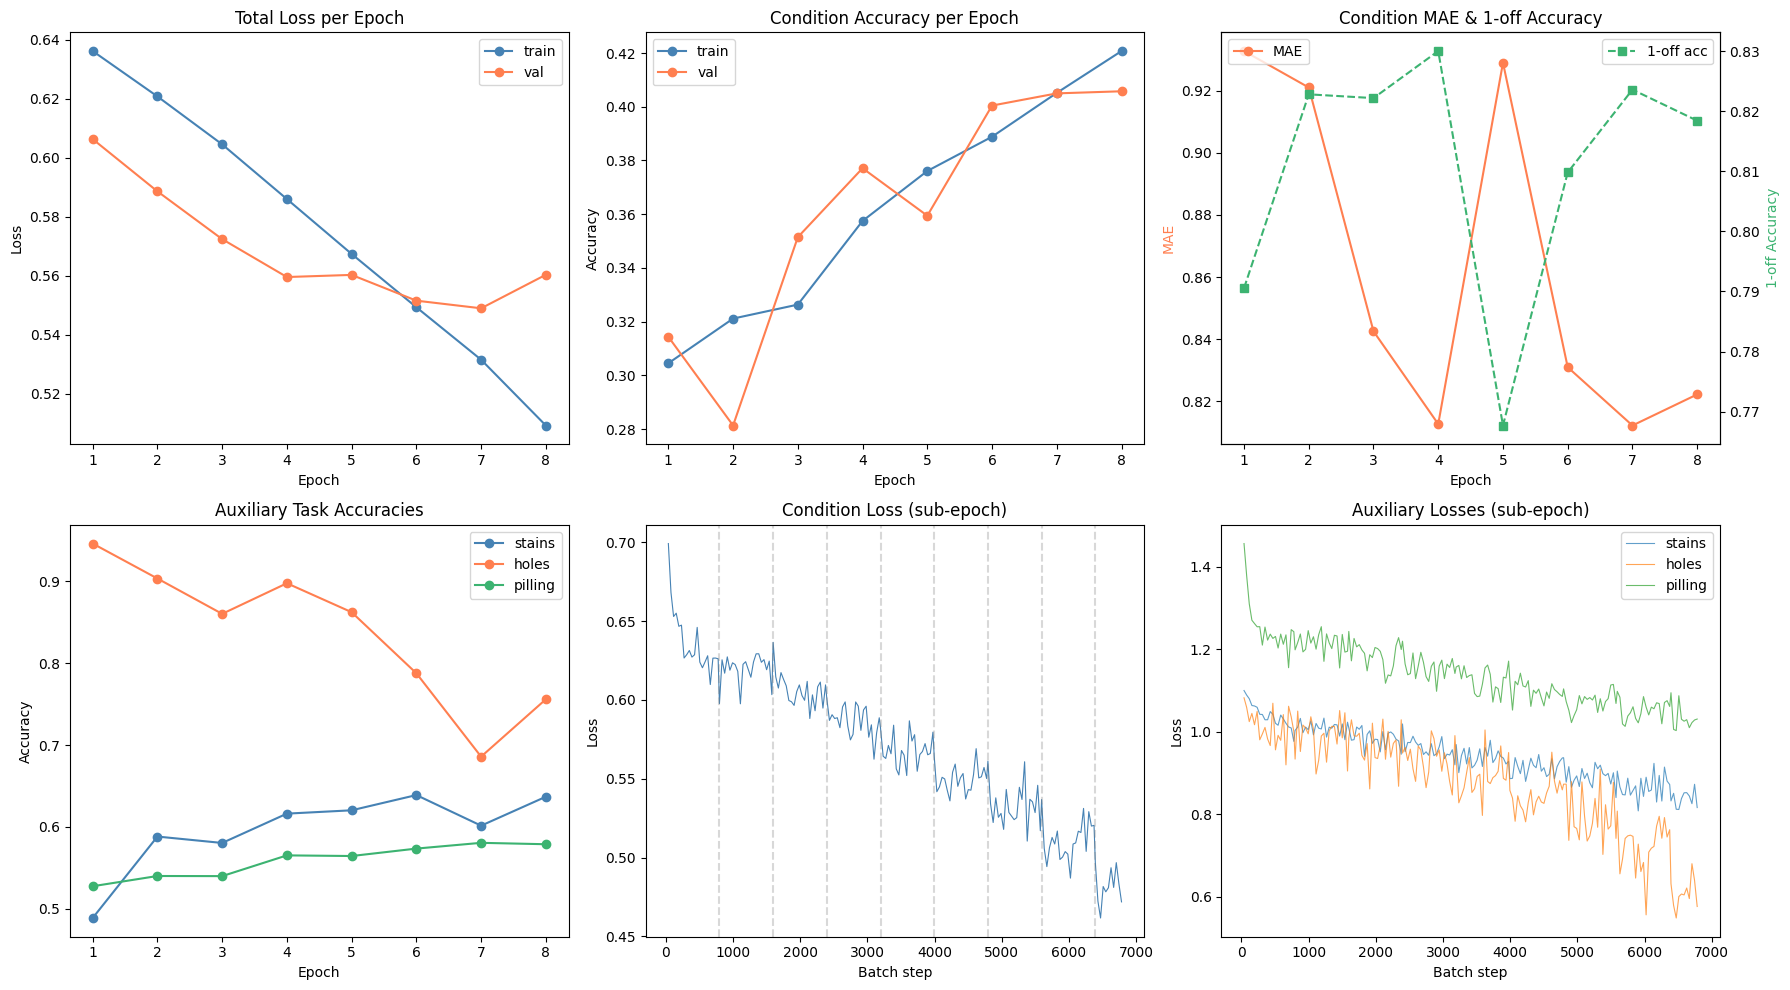

Saved to ../report/figures/v2_training_curves.png


In [12]:
import matplotlib.pyplot as plt

n_actual = len(history["train_loss"])
epochs = range(1, n_actual + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Train vs Val loss
axes[0, 0].plot(epochs, history["train_loss"], "o-", label="train", color="steelblue")
axes[0, 0].plot(epochs, history["val_loss"],   "o-", label="val",   color="coral")
axes[0, 0].set_title("Total Loss per Epoch")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

# 2. Condition accuracy
axes[0, 1].plot(epochs, history["train_acc"], "o-", label="train", color="steelblue")
axes[0, 1].plot(epochs, history["val_acc"],   "o-", label="val",   color="coral")
axes[0, 1].set_title("Condition Accuracy per Epoch")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy"); axes[0, 1].legend()

# 3. MAE and 1-off accuracy
ax3 = axes[0, 2]
ax3.plot(epochs, history["val_mae"], "o-", label="MAE", color="coral")
ax3.set_ylabel("MAE", color="coral")
ax3.set_title("Condition MAE & 1-off Accuracy")
ax3.set_xlabel("Epoch")
ax3b = ax3.twinx()
ax3b.plot(epochs, history["val_one_off"], "s--", label="1-off acc", color="mediumseagreen")
ax3b.set_ylabel("1-off Accuracy", color="mediumseagreen")
ax3.legend(loc="upper left"); ax3b.legend(loc="upper right")

# 4. Auxiliary task accuracies
axes[1, 0].plot(epochs, history["stains_acc"],  "o-", label="stains",  color="steelblue")
axes[1, 0].plot(epochs, history["holes_acc"],   "o-", label="holes",   color="coral")
axes[1, 0].plot(epochs, history["pilling_acc"], "o-", label="pilling", color="mediumseagreen")
axes[1, 0].set_title("Auxiliary Task Accuracies")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Accuracy"); axes[1, 0].legend()

# 5. Sub-epoch condition loss
axes[1, 1].plot(step_log["step"], step_log["cond_loss"], linewidth=0.8, color="steelblue")
axes[1, 1].set_title("Condition Loss (sub-epoch)")
axes[1, 1].set_xlabel("Batch step"); axes[1, 1].set_ylabel("Loss")
for e in range(1, n_actual + 1):
    axes[1, 1].axvline(x=e * len(train_loader), color="grey", linestyle="--", alpha=0.3)

# 6. Sub-epoch auxiliary losses
axes[1, 2].plot(step_log["step"], step_log["stains_loss"],  linewidth=0.8, label="stains", alpha=0.7)
axes[1, 2].plot(step_log["step"], step_log["holes_loss"],   linewidth=0.8, label="holes", alpha=0.7)
axes[1, 2].plot(step_log["step"], step_log["pilling_loss"], linewidth=0.8, label="pilling", alpha=0.7)
axes[1, 2].set_title("Auxiliary Losses (sub-epoch)")
axes[1, 2].set_xlabel("Batch step"); axes[1, 2].set_ylabel("Loss"); axes[1, 2].legend()

plt.tight_layout()
FIGURES_DIR = Path("../report/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "v2_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {FIGURES_DIR / 'v2_training_curves.png'}")

### Evaluation: Confusion Matrix & Classification Report

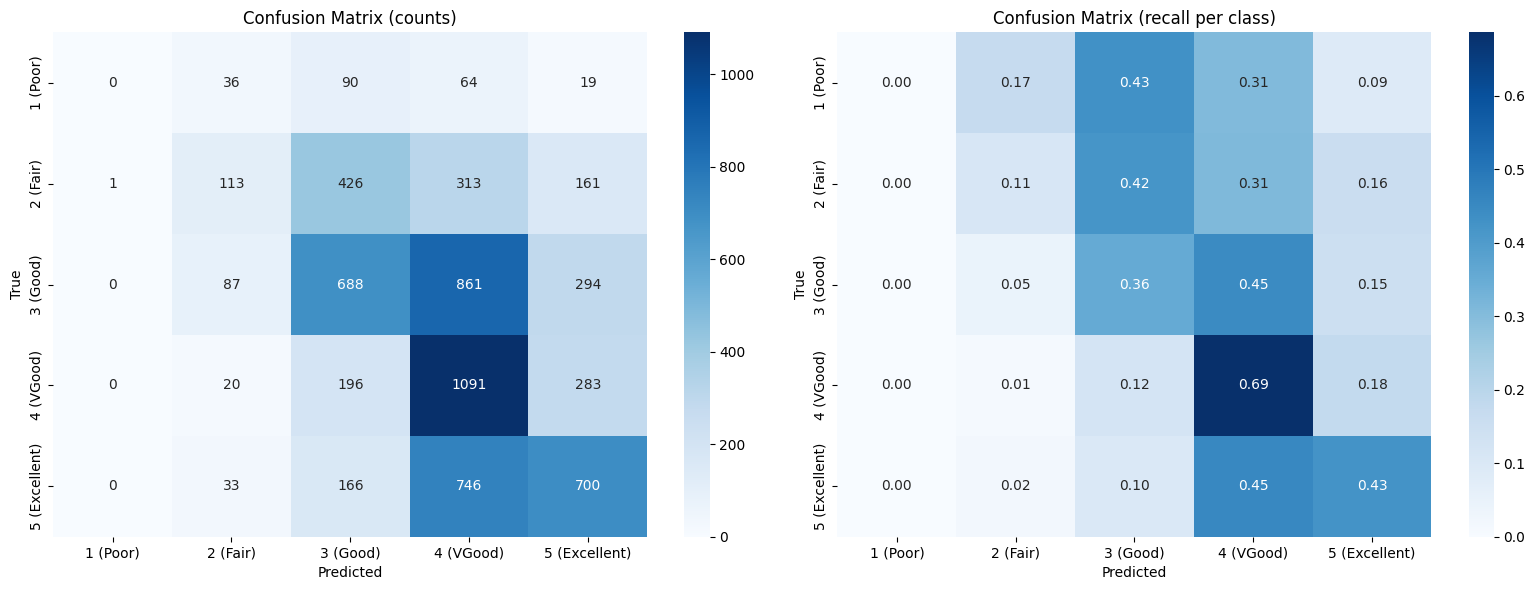


               precision    recall  f1-score   support

     1 (Poor)       0.00      0.00      0.00       209
     2 (Fair)       0.39      0.11      0.17      1014
     3 (Good)       0.44      0.36      0.39      1930
    4 (VGood)       0.35      0.69      0.47      1590
5 (Excellent)       0.48      0.43      0.45      1645

     accuracy                           0.41      6388
    macro avg       0.33      0.32      0.30      6388
 weighted avg       0.41      0.41      0.38      6388


  Condition Accuracy : 0.4058
  Condition MAE      : 0.822
  1-off Accuracy     : 0.8184
  Stains Accuracy    : 0.6368
  Holes Accuracy     : 0.7559
  Pilling Accuracy   : 0.5787


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Re-evaluate from best checkpoint if needed
if last_eval is None:
    ckpt = torch.load(SAVE_DIR / "best_checkpoint.pt", map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    last_eval = evaluate(model, test_loader)

preds_np   = last_eval["preds"]["condition"].numpy()
targets_np = last_eval["targets"]["condition"].numpy()

cond_labels = ["1 (Poor)", "2 (Fair)", "3 (Good)", "4 (VGood)", "5 (Excellent)"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
cm = confusion_matrix(targets_np, preds_np)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cond_labels, yticklabels=cond_labels, ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (counts)")

# Row-normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=cond_labels, yticklabels=cond_labels, ax=axes[1])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (recall per class)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + classification_report(targets_np, preds_np, target_names=cond_labels))

# Summary metrics
print(f"\n{'='*50}")
print(f"  Condition Accuracy : {last_eval['cond_acc']:.4f}")
print(f"  Condition MAE      : {last_eval['cond_mae']:.3f}")
print(f"  1-off Accuracy     : {last_eval['cond_one_off']:.4f}")
print(f"  Stains Accuracy    : {last_eval['stains_acc']:.4f}")
print(f"  Holes Accuracy     : {last_eval['holes_acc']:.4f}")
print(f"  Pilling Accuracy   : {last_eval['pilling_acc']:.4f}")
print(f"{'='*50}")

### Save Model for Fraud Pipeline

Export the trained model so `fraud_pipeline.ipynb` can load it for embedding extraction.

In [14]:
# Save just the model weights (smaller file for the fraud pipeline)
best_ckpt = torch.load(SAVE_DIR / "best_checkpoint.pt", map_location="cpu", weights_only=False)
torch.save(best_ckpt["model_state_dict"], SAVE_DIR / "best_model_v2.pt")
print(f"Saved model weights to {SAVE_DIR / 'best_model_v2.pt'}")
print(f"Best epoch: {best_ckpt['epoch']}")

Saved model weights to ../checkpoints_v2/best_model_v2.pt
Best epoch: 7
